In [1]:
import sklearn
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import proteinmlutils.featurizer as protfeat

In [2]:
protein_df=pd.read_csv("../data/A0A2Z5U3Z0_9INFA_Doud_2016.csv").sample(n=1000, random_state=42)
protein_df.rename(columns={"mutated_sequence": "protein_sequence"}, inplace=True)
protein_df

,mutant,protein_sequence,DMS_score,DMS_score_bin
10308,V544G,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.613682,0
6705,E354I,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.864511,0
304,D18T,MKAKLLVLLYAFVATDATTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.774094,0
9142,F483V,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.423986,0
10592,L559I,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.298089,0
...,...,...,...,...
3006,F160P,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-3.649694,0
1584,D85K,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-3.870769,0
9363,S494D,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-1.837786,1
10355,G547Y,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-3.386411,0


In [3]:
#check if the protein_sequence column has unique values
assert len(protein_df['protein_sequence'].unique()) == len(protein_df), "The 'protein_sequence' column does not have unique values"


In [4]:
protein_df['protein_sequence'].str.len().describe() # Check the maximum length of the protein sequences

count    1000.0
mean      565.0
std         0.0
min       565.0
25%       565.0
50%       565.0
75%       565.0
max       565.0
Name: protein_sequence, dtype: float64

In [5]:
max_length = int(protein_df['protein_sequence'].str.len().max())  # Get the maximum length of the sequences
sequence_arr = protein_df['protein_sequence'].tolist()
y_arr = protein_df['DMS_score'].tolist()


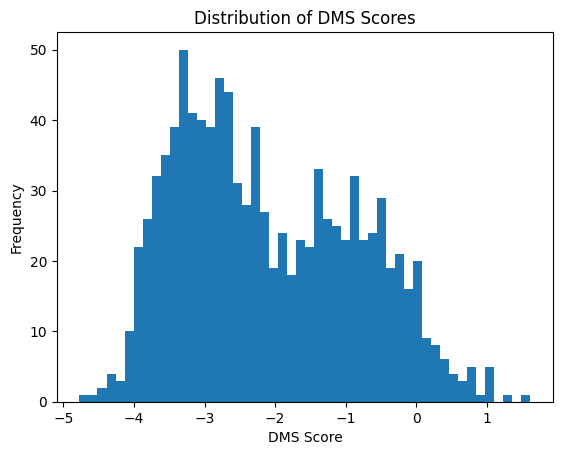

In [6]:
plt.hist(protein_df['DMS_score'], bins=50)
plt.xlabel('DMS Score')
plt.ylabel('Frequency')
plt.title('Distribution of DMS Scores')
plt.show()

In [7]:
y_discretize_arr=np.digitize(y_arr,bins=[-1])

In [8]:

X_arr=protfeat.protein_one_hot_encoder(sequence_arr, max_length=max_length, flatten=True)
print(X_arr.shape)  # Check the shape of the one-hot encoded array

(1000, 11865)


In [9]:
assert X_arr.shape == (len(protein_df), max_length * 21), "The shape of the one-hot encoded array does not match the expected shape"

In [10]:
embedding_dim = 5  # Set the embedding dimension
embedding_arr, embedding_weight=protfeat.protein_embedding_generator(sequence_arr, max_length, embedding_dim=embedding_dim, flatten=True)

In [11]:
assert embedding_arr.shape == (len(protein_df), max_length * embedding_dim), "The shape of the one-hot encoded array does not match the expected shape"

In [12]:
from proteinmlutils.ML_trainer import classifier_model_trainer
from proteinmlutils.data_stratifier import data_train_vs_test_splitting
X_train, X_test, y_train, y_test=data_train_vs_test_splitting(X_arr, y_discretize_arr, test_size=0.2)
kwargs = {}
kwargs['scoring'] = ["f1", "precision", "recall", "accuracy"]
kwargs['n_iter'] = 2
kwargs['primary_scoring'] = 'f1'

clf_trainer=classifier_model_trainer(X_train, y_train, **kwargs)
best_model_found, random_search_results_df=clf_trainer.RandomForestClassifier_trainer()
#.RandomForestClassifier_trainer

Training+validation sample size: 800
Test sample size: 200
Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=100, n_estimators=20, n_jobs=-1, random_state=0; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=100, n_estimators=20, n_jobs=-1, random_state=0; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=100, n_estimators=20, n_jobs=-1, random_state=0; total time=   0.0s


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=50, n_estimators=20, n_jobs=-1, random_state=0; total time=   0.1s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=50, n_estimators=20, n_jobs=-1, random_state=0; total time=   0.0s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=50, n_estimators=20, n_jobs=-1, random_state=0; total time=   0.0s
Score on training: Recall= 0.0 Precision= 0.0 F1 score= 0.0


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [16]:

y_pred_train=best_model_found.predict(X_train)
print("Score on training: Recall=", sk.metrics.recall_score(self.y_train,y_pred_train), "Precision=", sk.metrics.precision_score(self.y_train,y_pred_train), "F1 score=",sk.metrics.f1_score(self.y_train, y_pred_train))

NameError: name 'self' is not defined